## Imports

In [13]:
import pandas as pd ## For reading and manipulating datasets
import matplotlib.pyplot as plt ## used for graph visualization
import seaborn as sns ## used for graph visualization
from sklearn.model_selection import train_test_split ## used to split the dataset for training and testing
from sklearn.linear_model import LogisticRegression ## to use logistic regression model
from sklearn.model_selection import GridSearchCV # used for tuning algorithms and hyperparameters
import warnings ## to remove the warnings
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score ## metric for evaluation of the models
from sklearn.model_selection import cross_val_score ## to use cross validation
import numpy as np ## for numerical computing
from scipy import stats ## For statistical functions and tests.
from sklearn.model_selection import KFold ## for cross validation
from imblearn.over_sampling import SMOTE ## for handling imbalanced datasets using SMOTE
from sklearn.preprocessing import StandardScaler

## ignoring all warnings
warnings.filterwarnings("ignore")
## used to show graphs
%matplotlib inline

In [14]:
from pathlib import Path
# Use the CSV file located in the same folder as this notebook
path = str(Path.cwd() / "sepsis_cleaned.csv")
df_new = pd.read_csv(path, encoding= 'latin-1')  ## how we load a dataset, traditionally we use the word df but you can call it whatever you want
print("There are " + str(len(df_new)) + " data point.")  # check the number of datapoints  aka the number of rows
#df_new.head() 
###############################################
path2 = str(Path.cwd() / "sepsis_final_data_RAW_withTimes.csv")
df_new2 = pd.read_csv(path2, encoding= 'latin-1')  ## how we load a dataset, traditionally we use the word df but you can call it whatever you want
print("There are " + str(len(df_new2)) + " data point.")  # check the number of datapoints  aka the number of rows
df_new2.head()



There are 1551276 data point.
There are 247210 data point.


,traj,step,m:presumed_onset,m:charttime,m:icustayid,o:gender,o:mechvent,o:max_dose_vaso,o:re_admission,o:age,...,o:SGOT,o:SGPT,o:Total_bili,o:INR,o:input_total,o:input_4hourly,o:output_total,o:output_4hourly,a:action,r:reward
0,1,0,7.245590e+09,7.245486e+09,200003.0,0.0,0.0,0.0,0.0,17639.826435,...,66.0,44.0,0.5,1.3,6527.0,50.0,13617.0,520.0,10,0.0
1,1,1,7.245590e+09,7.245500e+09,200003.0,0.0,0.0,0.0,0.0,17639.826435,...,38.0,30.0,5.2,1.0,6577.0,50.0,13982.0,365.0,10,0.0
2,1,2,7.245590e+09,7.245515e+09,200003.0,0.0,0.0,0.0,0.0,17639.826435,...,38.0,30.0,5.2,1.0,6627.0,50.0,14262.0,280.0,10,0.0
3,1,3,7.245590e+09,7.245529e+09,200003.0,0.0,0.0,0.0,0.0,17639.826435,...,38.0,30.0,5.2,1.3,6677.0,50.0,14602.0,340.0,10,0.0
4,1,4,7.245590e+09,7.245544e+09,200003.0,0.0,0.0,0.0,0.0,17639.826435,...,38.0,30.0,5.2,1.3,6727.0,50.0,15142.0,540.0,10,0.0


In [4]:
df_new2.columns.tolist()

['traj',
 'step',
 'm:presumed_onset',
 'm:charttime',
 'm:icustayid',
 'o:gender',
 'o:mechvent',
 'o:max_dose_vaso',
 'o:re_admission',
 'o:age',
 'o:Weight_kg',
 'o:GCS',
 'o:HR',
 'o:SysBP',
 'o:MeanBP',
 'o:DiaBP',
 'o:RR',
 'o:Temp_C',
 'o:FiO2_1',
 'o:Potassium',
 'o:Sodium',
 'o:Chloride',
 'o:Glucose',
 'o:Magnesium',
 'o:Calcium',
 'o:Hb',
 'o:WBC_count',
 'o:Platelets_count',
 'o:PTT',
 'o:PT',
 'o:Arterial_pH',
 'o:paO2',
 'o:paCO2',
 'o:Arterial_BE',
 'o:HCO3',
 'o:Arterial_lactate',
 'o:SOFA',
 'o:SIRS',
 'o:Shock_Index',
 'o:PaO2_FiO2',
 'o:cumulated_balance',
 'o:SpO2',
 'o:BUN',
 'o:Creatinine',
 'o:SGOT',
 'o:SGPT',
 'o:Total_bili',
 'o:INR',
 'o:input_total',
 'o:input_4hourly',
 'o:output_total',
 'o:output_4hourly',
 'a:action',
 'r:reward']

In [15]:
cols_to_keep = [
    "o:HR",
    "o:SpO2",
    "o:Temp_C",
    "o:SysBP",
    "o:MeanBP",
    "o:DiaBP",
    "o:RR",
    "o:age",
    "o:gender"
]

df_new2_reduced = df_new2[cols_to_keep].copy()

# FIX: Convert Age from days to years to match df_new format
df_new2_reduced["o:age"] = df_new2_reduced["o:age"] / 365.0
print(f"Age converted from days to years. New range: {df_new2_reduced['o:age'].min():.1f} - {df_new2_reduced['o:age'].max():.1f} years")

df_new2_reduced.head()

Age converted from days to years. New range: 18.0 - 91.5 years


,o:HR,o:SpO2,o:Temp_C,o:SysBP,o:MeanBP,o:DiaBP,o:RR,o:age,o:gender
0,74.571429,97.428571,37.858333,104.714286,72.857143,56.000000,22.857143,48.328292,0.0
1,68.333333,98.333333,37.800000,103.833333,70.333333,55.333333,22.333333,48.328292,0.0
2,70.200000,97.800000,37.800000,111.000000,75.200000,57.200000,20.200000,48.328292,0.0
3,78.000000,97.200000,37.757143,117.400000,79.400000,60.200000,18.800000,48.328292,0.0
4,77.000000,97.200000,37.222222,114.200000,78.600000,66.600000,24.600000,48.328292,0.0


In [16]:
df_new2_reduced["ICULOS"] = np.nan
df_new2_reduced["SepsisLabel"] = 1
df_new2_reduced.head()

,o:HR,o:SpO2,o:Temp_C,o:SysBP,o:MeanBP,o:DiaBP,o:RR,o:age,o:gender,ICULOS,SepsisLabel
0,74.571429,97.428571,37.858333,104.714286,72.857143,56.000000,22.857143,48.328292,0.0,NaN,1
1,68.333333,98.333333,37.800000,103.833333,70.333333,55.333333,22.333333,48.328292,0.0,NaN,1
2,70.200000,97.800000,37.800000,111.000000,75.200000,57.200000,20.200000,48.328292,0.0,NaN,1
3,78.000000,97.200000,37.757143,117.400000,79.400000,60.200000,18.800000,48.328292,0.0,NaN,1
4,77.000000,97.200000,37.222222,114.200000,78.600000,66.600000,24.600000,48.328292,0.0,NaN,1


In [17]:
# Rename columns in df_new2_reduced to match df_new (remove 'o:' prefix)
column_mapping = {
    'o:HR': 'HR',
    'o:SpO2': 'O2Sat',
    'o:Temp_C': 'Temp',
    'o:SysBP': 'SBP',
    'o:MeanBP': 'MAP',
    'o:DiaBP': 'DBP',
    'o:RR': 'Resp',
    'o:age': 'Age',
    'o:gender': 'Gender'
}

df_new2_renamed = df_new2_reduced.rename(columns=column_mapping)

# Reindex df_new2_renamed to match df_new's columns (same order and shape)
# Missing columns will be filled with NaN
df_new2_aligned = df_new2_renamed.reindex(columns=df_new.columns)

# Concatenate preserving df_new's column order
df_merged = pd.concat([df_new, df_new2_aligned], ignore_index=True)

print("There are " + str(len(df_merged)) + " data point.")
# Count how many 1s and 0s in SepsisLabel
counts = df_merged['SepsisLabel'].value_counts()
print(counts)
df_merged.head()

There are 1798486 data point.
SepsisLabel
0    1523370
1     275116
Name: count, dtype: int64


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,Gender,ICULOS,SepsisLabel
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0.0,1.0,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,83.14,0.0,2.0,0
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,83.14,0.0,3.0,0
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,83.14,0.0,4.0,0
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,83.14,0.0,5.0,0


In [8]:
# Show examples where SepsisLabel is 1
# print("Examples where SepsisLabel = 1:")
# print(f"Total count: {df_new[df_new['SepsisLabel'] == 1].shape[0]}")
# df_new[df_new['SepsisLabel'] == 1].head()
################################
print("Examples where SepsisLabel = 1:")
print(f"Total count: {df_merged[df_merged['SepsisLabel'] == 1].shape[0]}")
df_merged[df_merged['SepsisLabel'] == 1].head()

Examples where SepsisLabel = 1:
Total count: 275116


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,Gender,ICULOS,SepsisLabel
552,119.0,100.0,37.94,140.0,106.0,85.0,26.5,27.92,1.0,249.0,1
553,118.0,96.0,NaN,138.0,108.0,88.0,26.0,27.92,1.0,250.0,1
554,111.0,97.0,37.39,136.0,106.0,86.0,26.0,27.92,1.0,251.0,1
555,116.0,96.0,37.72,143.0,109.0,88.0,30.0,27.92,1.0,252.0,1
556,120.0,97.0,NaN,138.0,106.0,85.0,32.0,27.92,1.0,253.0,1


In [22]:
# Count rows with any NaN values and show NaN summary
# This cell assumes `df` is already loaded in the notebook (from `sepsis_cleaned.csv`).
rows_with_nan = df_merged.isnull().any(axis=1).sum()
total_nans = df_merged.isnull().sum().sum()
rows_without_nan = df_merged.notnull().all(axis=1).sum()
print(f"Rows without any NaN: {rows_without_nan}")
print(f"Rows with at least one NaN: {rows_with_nan}")
print(f"Total NaN values in dataset: {total_nans}")




Rows without any NaN: 398773
Rows with at least one NaN: 1399713
Total NaN values in dataset: 2773206


In [40]:
#df_new = df.dropna()
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df_new.drop(columns=['SepsisLabel']))
X = pd.DataFrame(X_imputed, columns=df_new.drop(columns=['SepsisLabel']).columns)
y = df_new['SepsisLabel']

In [18]:
## We separate attributes from target variable (using balanced dataset)
##features = df_new.iloc[:, :-1]
##labels = df_new.iloc[:, -1]
X = df_merged.drop(columns=['SepsisLabel'])
y = df_merged['SepsisLabel']

## Divide the dataset into 80% training and 20% testing. X corresponds to the attributes while y corresponds to the target variable
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, stratify=y,random_state=8)



In [19]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for handling imbalanced data
# This tells XGBoost how much to weight the minority class
#scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight =  ((y_train == 0).sum() / (y_train == 1).sum())

print(f"Scale pos weight (ratio of negative to positive): {scale_pos_weight:.2f}")

# Create XGBoost model with scale_pos_weight to handle imbalance
xgb_model = XGBClassifier(
    random_state=8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

Scale pos weight (ratio of negative to positive): 5.54


In [20]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

search_space = {
    'n_estimators': Integer(50, 300),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'min_child_weight': Integer(1, 10),
    'gamma': Real(0, 0.5),
    'reg_alpha': Real(1e-9, 1.0, prior='log-uniform'),
    'reg_lambda': Real(1e-9, 1.0, prior='log-uniform')
}

In [21]:
# Perform Bayesian optimization with cross-validation
bayes_search = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=search_space,
    n_iter=1,  # Number of parameter settings to sample
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    scoring='recall_weighted',  # Optimize for recall (good for imbalanced data)
    verbose=1,
    random_state=8
)

# Fit on original unbalanced training data (XGBoost handles imbalance internally)
bayes_search.fit(X_train, y_train)

# Get the best model
best_model = bayes_search.best_estimator_

print(f"\nBest parameters: {bayes_search.best_params_}")
print(f"Best cross-validation F1 score: {bayes_search.best_score_:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best parameters: OrderedDict([('colsample_bytree', 0.6264864514226891), ('gamma', 0.22623207339483786), ('learning_rate', 0.01279260805407756), ('max_depth', 8), ('min_child_weight', 1), ('n_estimators', 187), ('reg_alpha', 3.272315546878636e-05), ('reg_lambda', 5.865559646814994e-08), ('subsample', 0.6206911196871939)])
Best cross-validation F1 score: 0.9821


In [22]:
# Evaluate the best model on test set
y_test_pred = best_model.predict(X_test)

# Calculate and print the test metrics
from sklearn.metrics import roc_auc_score
y_proba = best_model.predict_proba(X_test)[:, 1]

# # Calculate the AUC score
auc_score = roc_auc_score(y_test, y_proba)
print(f"AUC Score: {auc_score:.4f}")

# # Print detailed classification report
# from sklearn.metrics import classification_report
# print("\nDetailed Classification Report:")
# print(classification_report(y_test, y_test_pred, target_names=['No Sepsis', 'Sepsis']))

from sklearn.metrics import classification_report

for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    y_pred = (y_proba >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['No Sepsis', 'Sepsis']
    ))


AUC Score: 0.9730

Threshold = 0.5
              precision    recall  f1-score   support

   No Sepsis       0.98      1.00      0.99    304675
      Sepsis       0.98      0.91      0.94     55023

    accuracy                           0.98    359698
   macro avg       0.98      0.95      0.96    359698
weighted avg       0.98      0.98      0.98    359698


Threshold = 0.4
              precision    recall  f1-score   support

   No Sepsis       0.98      0.98      0.98    304675
      Sepsis       0.91      0.92      0.91     55023

    accuracy                           0.97    359698
   macro avg       0.95      0.95      0.95    359698
weighted avg       0.97      0.97      0.97    359698


Threshold = 0.3
              precision    recall  f1-score   support

   No Sepsis       0.99      0.95      0.97    304675
      Sepsis       0.79      0.93      0.85     55023

    accuracy                           0.95    359698
   macro avg       0.89      0.94      0.91    359698
weigh

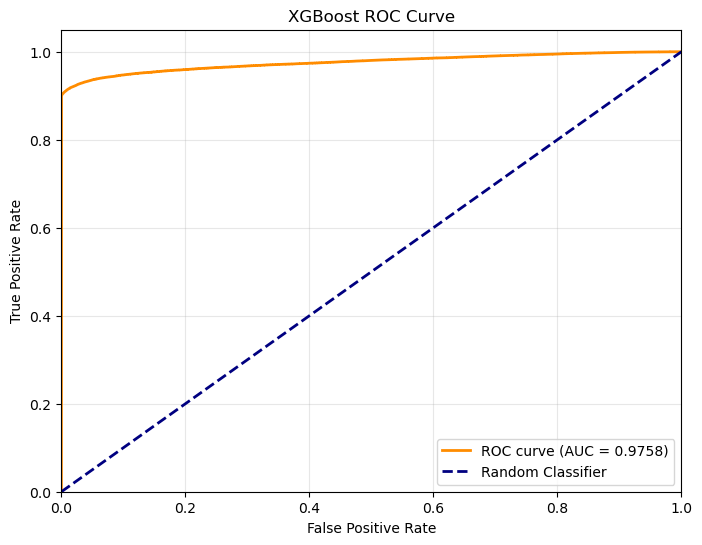

In [14]:
# Plot ROC curve with AUC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## Save Model for Deployment
Save the trained XGBoost model and feature information for web deployment.